#Loading Required Libraries

In [ ]:
import pandas as pd
import os
import zipfile


#Performing EDA


##Step 1:Data Loading and Inspection

###Data Loading

In [ ]:
import pandas as pd
import os
import zipfile

# 1. Load a safe sample of the massive file without crashing Colab RAM
zip_file_path = '/content/sample_data/rows.csv.zip'
extraction_dir = '/content/extracted_data'
extracted_csv_path = os.path.join(extraction_dir, 'rows.csv')

# Check if the zip file exists
if not os.path.exists(zip_file_path):
    print(f"Error: The zip file '{zip_file_path}' was not found. Please ensure the file is uploaded and the path is correct.")
else:
    print(f"Extracting data from {zip_file_path}...")
    os.makedirs(extraction_dir, exist_ok=True)
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_dir)
        print(f"Successfully extracted to {extraction_dir}")

        # Now read the extracted CSV file
        print("Loading data sample from extracted CSV...")
        # We revert to default sep and encoding, as the extracted file should be a standard CSV
        df = pd.read_csv(extracted_csv_path, nrows=30000, low_memory=False)

        # 2. Build a clean summary table of null counts and percentages per column
        null_summary = pd.DataFrame({
            'Column Name': df.columns,
            'Null Count': df.isnull().sum().values,
            'Null Percentage (%)': (df.isnull().mean().values * 100).round(2)
        })

        # 3. Display the final structured report
        print(f"\nSuccessfully loaded {len(df)} rows for analysis.\n")
        print(null_summary.to_string(index=False))

    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is not a valid zip file. Please check the file's integrity.")
    except Exception as e:
        print(f"An error occurred during extraction or loading: {e}")


Extracting data from /content/sample_data/rows.csv.zip...
Successfully extracted to /content/extracted_data
Loading data sample from extracted CSV...

Successfully loaded 30000 rows for analysis.

                 Column Name  Null Count  Null Percentage (%)
               Date received           0                 0.00
                     Product           0                 0.00
                 Sub-product           0                 0.00
                       Issue           0                 0.00
                   Sub-issue        3792                12.64
Consumer complaint narrative       29999               100.00
     Company public response       16867                56.22
                     Company           0                 0.00
                       State        1042                 3.47
                    ZIP code        4309                14.36
                        Tags       25800                86.00
  Consumer consent provided?       24744                82.

###Data Inspection

In [ ]:
#Checking the number of rows and columns
df.shape

(30000, 18)

In [ ]:
#Viewing the column names in the dataset
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [ ]:
print("--- Identifying Numerical and Categorical Variables ---")

# Identify numerical variables
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumerical Variables ({len(numerical_cols)}):\n{numerical_cols}")

# Identify categorical variables (object type columns)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical Variables ({len(categorical_cols)}):\n{categorical_cols}")

print("\n--- Identification Complete ---")

--- Identifying Numerical and Categorical Variables ---

Numerical Variables (2):
['Consumer disputed?', 'Complaint ID']

Categorical Variables (16):
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?']

--- Identification Complete ---


####Viewing first 10 rows

In [ ]:
#Viewing first 10 rows
df.head(10)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460
5,05/10/2019,Mortgage,Other type of mortgage,Closing on a mortgage,NaN,NaN,NaN,Statebridge Company,NJ,08302,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237885
6,05/10/2019,Debt collection,Other debt,Attempts to collect debt not owed,Debt is not yours,NaN,NaN,"Diversified Consultants, Inc.",TX,NaN,Servicemember,NaN,Web,05/10/2019,In progress,Yes,NaN,3238585
7,05/10/2019,Student loan,Federal student loan servicing,Struggling to repay your loan,Problem lowering your monthly payments,NaN,NaN,Student Loan Direct,TX,773XX,Older American,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238221
8,05/10/2019,Debt collection,Other debt,Attempts to collect debt not owed,Debt was paid,NaN,NaN,"Diversified Consultants, Inc.",SC,296XX,Servicemember,NaN,Web,05/10/2019,In progress,Yes,NaN,3238545
9,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,CONTRACT CALLERS INC,MD,20774,NaN,NaN,Web,05/10/2019,In progress,Yes,NaN,3238458


In [ ]:
#Viewing last 10 rows
df.tail(10)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
29990,03/23/2019,Credit card or prepaid card,Store credit card,Credit monitoring or identity theft protection...,Billing dispute for services,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,FL,328XX,NaN,NaN,Web,03/23/2019,Closed with explanation,Yes,NaN,3188881
29991,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,"EQUIFAX, INC.",KY,410XX,NaN,NaN,Web,03/23/2019,In progress,Yes,NaN,3188757
29992,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,"CITIBANK, N.A.",LA,70460,NaN,NaN,Fax,03/29/2019,Closed with explanation,Yes,NaN,3188921
29993,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Improper use of your report,Credit inquiries on your report that you don't...,NaN,NaN,"EQUIFAX, INC.",FL,325XX,NaN,NaN,Web,03/23/2019,Closed with explanation,Yes,NaN,3189148
29994,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"EQUIFAX, INC.",TX,77532,NaN,NaN,Web,03/23/2019,In progress,Yes,NaN,3189155
29995,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,"EQUIFAX, INC.",IL,NaN,NaN,NaN,Web,03/23/2019,In progress,Yes,NaN,3189126
29996,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NC,27502,NaN,Consent not provided,Web,03/23/2019,Closed with explanation,Yes,NaN,3189235
29997,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,NaN,Company has responded to the consumer and the ...,"BANK OF AMERICA, NATIONAL ASSOCIATION",SC,291XX,NaN,NaN,Web,03/23/2019,Closed with explanation,Yes,NaN,3188809
29998,03/23/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,WORLD ACCEPTANCE CORPORATION,IL,NaN,NaN,NaN,Web,03/23/2019,Closed with explanation,Yes,NaN,3189123
29999,03/23/2019,Debt collection,Other debt,Attempts to collect debt not owed,Debt is not yours,NaN,NaN,"Convergent Resources, Inc.",CA,95054,NaN,NaN,Web,04/05/2019,Closed with explanation,Yes,NaN,3188556


In [ ]:
#Inspecting data types
df.dtypes

,0
Date received,object
Product,object
Sub-product,object
Issue,object
Sub-issue,object
Consumer complaint narrative,object
Company public response,object
Company,object
State,object
ZIP code,object


In [ ]:
#Viewing total variables for each data type
df.dtypes.value_counts()

,count
object,16
float64,1
int64,1


##Step 2: Data Cleaning and Missing Values

###Data Cleaning

In [ ]:
#Looking for duplicate rows
dup_vals = df.duplicated().sum()
print("There are ", dup_vals, " duplicate rows")

There are  0  duplicate rows


In [ ]:
#Finding irrelevant values
import pandas as pd

# Assuming your DataFrame 'df' is already loaded from your extracted CSV
print("--- Scanning Columns for Irrelevant or Anomalous Values --\n")

for col in df.columns:
  print(f"Column: '{col}' (Type: {df[col].dtype})")

  # 1. For categorical/text columns: check for top values, weird characters, or rare typos
  if df[col].dtype == 'object':
    # Get value counts of unique entries
    val_counts = df[col].value_counts(dropna=False)

    print(f"  - Total unique values: {df[col].nunique()}")
    print("  - Top 5 most frequent values:")
    print(val_counts.head(5).to_string())

    # If there are very few unique categories, show all of them to spot typos easily
    if df[col].nunique() < 15:
      print("  - All categories breakdown:")
      print(val_counts.to_string())

  # 2. For numeric columns: check for negative numbers or unreasonable values if applicable
  elif pd.api.types.is_numeric_dtype(df[col]):
    print(f"  - Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"  - Negative values count: (df[col] < 0).sum()")

  print("-" * 50)

--- Scanning Columns for Irrelevant or Anomalous Values --

Column: 'Date received' (Type: object)
  - Total unique values: 49
  - Top 5 most frequent values:
Date received
04/11/2019    1081
04/02/2019    1063
04/09/2019    1041
04/17/2019    1027
03/26/2019     995
--------------------------------------------------
Column: 'Product' (Type: object)
  - Total unique values: 9
  - Top 5 most frequent values:
Product
Credit reporting, credit repair services, or other personal consumer reports    14935
Debt collection                                                                  5219
Credit card or prepaid card                                                      2700
Mortgage                                                                         2471
Checking or savings account                                                      2220
  - All categories breakdown:
Product
Credit reporting, credit repair services, or other personal consumer reports    14935
Debt collection            

In [ ]:
#Handling irrelevant values
print("Handling irrelevant values (missing data):")

# Identify columns to drop due to 100% missing values
# 'Consumer disputed?' is float64 but 100% null, effectively irrelevant as a numerical feature.
# 'Consumer complaint narrative' is object and 100% null.
columns_to_drop = [
    'Consumer disputed?',
    'Consumer complaint narrative'
]

df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
print(f"\nDropped columns with 100% missing values: {columns_to_drop}")

# Impute missing values in other non-numerical (object) columns
# using specific placeholder strings.
object_cols_to_impute = {
    'Tags': 'No Tag',
    'Consumer consent provided?': 'Not Provided',
    'Company public response': 'No Response',
    'Sub-issue': 'Unknown Sub-issue',
    'State': 'Unknown',
    'ZIP code': 'Unknown'
}

for col, placeholder in object_cols_to_impute.items():
    if col in df_cleaned.columns:
        original_nulls = df_cleaned[col].isnull().sum()
        if original_nulls > 0:
            df_cleaned[col] = df_cleaned[col].fillna(placeholder)
            print(f"Filled {original_nulls} missing values in '{col}' with '{placeholder}'")

# Re-calculate and display the null summary for the cleaned DataFrame
null_summary_cleaned = pd.DataFrame({
    'Column Name': df_cleaned.columns,
    'Null Count': df_cleaned.isnull().sum().values,
    'Null Percentage (%)': (df_cleaned.isnull().mean().values * 100).round(2)
})

print("\nUpdated Null Summary after handling irrelevant values:")
print(null_summary_cleaned.to_string(index=False))

df = df_cleaned.copy() # Update the main DataFrame 'df' with the cleaned version

Handling irrelevant values (missing data):

Dropped columns with 100% missing values: ['Consumer disputed?', 'Consumer complaint narrative']

Updated Null Summary after handling irrelevant values:
                 Column Name  Null Count  Null Percentage (%)
               Date received           0                  0.0
                     Product           0                  0.0
                 Sub-product           0                  0.0
                       Issue           0                  0.0
                   Sub-issue           0                  0.0
     Company public response           0                  0.0
                     Company           0                  0.0
                       State           0                  0.0
                    ZIP code           0                  0.0
                        Tags           0                  0.0
  Consumer consent provided?           0                  0.0
               Submitted via           0                  0

In [ ]:
#Verifying if the irrelevant values have been adressed
print("--- DATA CLEANING VERIFICATION REPORT ---\n")

# 1. Verify Categorical/Text Columns (Check for whitespace, casing, and unique count changes)
print("=== CATEGORICAL COLUMNS CHECK ===")
for col in df.select_dtypes(include=['object', 'category']).columns:
  unique_count = df[col].nunique()
  sample_values = df[col].dropna().unique()[:5]  # First 5 unique values

  print(f"Column: '{col}'")
  print(f"  - Total Unique Values: {unique_count}")
  print(f"  - Sample Values: {list(sample_values)}")

  # Check for lingering leading/trailing whitespaces
  whitespace_check = df[col].astype(str).str.contains(r'^\s+|\s+$', regex=True).sum()
  print(f"  - Rows with leading/trailing spaces: {whitespace_check}")
  print("-" * 40)

# 2. Verify Numerical Columns (Check for min, max, and remaining negative values)
print("\n=== NUMERICAL COLUMNS CHECK ===")
numeric_cols = df.select_dtypes(include=['number']).columns

if len(numeric_cols) > 0:
  num_summary = pd.DataFrame({
      'Min Value': df[numeric_cols].min(),
      'Max Value': df[numeric_cols].max(),
      'Mean': df[numeric_cols].mean().round(2),
      'Null Count': df[numeric_cols].isnull().sum()
  })
  print(num_summary.to_string())
else:
  print("No numerical columns found in the DataFrame.")

print("\n--- Verification Complete ---")

--- DATA CLEANING VERIFICATION REPORT ---

=== CATEGORICAL COLUMNS CHECK ===
Column: 'Date received'
  - Total Unique Values: 49
  - Sample Values: ['05/10/2019', '05/09/2019', '05/08/2019', '05/07/2019', '05/06/2019']
  - Rows with leading/trailing spaces: 0
----------------------------------------
Column: 'Product'
  - Total Unique Values: 9
  - Sample Values: ['Checking or savings account', 'Debt collection', 'Credit reporting, credit repair services, or other personal consumer reports', 'Mortgage', 'Student loan']
  - Rows with leading/trailing spaces: 0
----------------------------------------
Column: 'Sub-product'
  - Total Unique Values: 46
  - Sample Values: ['Checking account', 'Other banking product or service', 'Payday loan debt', 'Credit reporting', 'Other type of mortgage']
  - Rows with leading/trailing spaces: 0
----------------------------------------
Column: 'Issue'
  - Total Unique Values: 78
  - Sample Values: ['Managing an account', 'Communication tactics', 'Incorre

In [ ]:
#Checking and Fixing Incorrect Values
import pandas as pd

# 1. Check for impossible dates (e.g., complaints received in the future or way in the past)
df['Date received'] = pd.to_datetime(df['Date received'], errors='coerce')
invalid_dates = df[df['Date received'] > pd.to_datetime('today')]
print(f"Rows with future dates: {len(invalid_dates)}")

# 2. Handle missing/null values in critical columns
# Fill missing text descriptions with a placeholder
df['Consumer complaint narrative'] = df['Consumer complaint narrative'].fillna('No narrative provided')

# Drop rows where essential identifiers like 'Product' or 'Complaint ID' are missing
df = df.dropna(subset=['Product', 'Complaint ID'])

Rows with future dates: 0


In [ ]:
#Standardizing data formatting
# 1. Clean string columns (strip whitespace and convert text to title case for consistency)
text_columns = ['Product', 'Sub-product', 'Issue', 'Company']

for col in text_columns:
  if col in df.columns:
    df[col] = df[col].astype(str).str.strip().str.title()

# 2. Extract useful date features for analysis (Year, Month, Day of Week)
if 'Date received' in df.columns:
  df['Complaint_Year'] = df['Date received'].dt.year
  df['Complaint_Month'] = df['Date received'].dt.month
  df['Complaint_DayOfWeek'] = df['Date received'].dt.day_name()

###Cleaning Missing Values

In [ ]:
#Checking for the presence of null values
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Date received,0
Product,0
Sub-product,0
Issue,0
Sub-issue,3792
Consumer complaint narrative,0
Company public response,16867
Company,0
State,1042
ZIP code,4309


In [ ]:
import pandas as pd

# Handle NaN values in the dataset

# Identify columns with NaN values
nan_cols = df.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]

print("Columns with NaN values before handling:")
print(nan_cols)

# Columns to fill with specific placeholders (object type)
object_cols_to_fill = {
    'Sub-issue': 'Unknown Sub-issue',
    'Company public response': 'No Response',
    'State': 'Unknown',
    'ZIP code': 'Unknown',
    'Tags': 'No Tag',
    'Consumer consent provided?': 'Not Provided'
}

for col, placeholder in object_cols_to_fill.items():
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(placeholder)
        print(f"Filled NaN values in '{col}' with '{placeholder}'.")

# Handle 'Consumer disputed?' column
# It's a float64 column with 100% NaN values, making it effectively useless without specific imputation logic.
# Given its nature, it's best to drop it, aligning with a previous attempt to do so.
if 'Consumer disputed?' in df.columns and df['Consumer disputed?'].isnull().all():
    df = df.drop(columns=['Consumer disputed?'])
    print("Dropped 'Consumer disputed?' column as it contained 100% NaN values.")
elif 'Consumer disputed?' in df.columns and df['Consumer disputed?'].isnull().any():
    # If not 100% NaN, consider a different imputation strategy for a boolean-like float column
    # For now, assuming it's 100% NaN based on context.
    # If it was mixed, one might convert to object and fill with 'Unknown' or impute with mode/0/False.
    print("The 'Consumer disputed?' column has some NaN values but not 100%. Manual review recommended.")

# Verify that all NaN values have been addressed
print("\nNaN values after handling:")
remaining_nan = df.isnull().sum()[df.isnull().sum() > 0]
print(remaining_nan)

if remaining_nan.empty:
    print("\nAll NaN values in the dataset have been handled.")
else:
    print("\nThere are still some NaN values in the dataset. Please review.")

Columns with NaN values before handling:
Sub-issue                      3792
Company public response       16867
State                          1042
ZIP code                       4309
Tags                          25800
Consumer consent provided?    24744
Consumer disputed?            30000
dtype: int64
Filled NaN values in 'Sub-issue' with 'Unknown Sub-issue'.
Filled NaN values in 'Company public response' with 'No Response'.
Filled NaN values in 'State' with 'Unknown'.
Filled NaN values in 'ZIP code' with 'Unknown'.
Filled NaN values in 'Tags' with 'No Tag'.
Filled NaN values in 'Consumer consent provided?' with 'Not Provided'.
Dropped 'Consumer disputed?' column as it contained 100% NaN values.

NaN values after handling:
Series([], dtype: int64)

All NaN values in the dataset have been handled.


In [ ]:
#Verifying if all NaN values are handled
df.isnull().sum().sum()

np.int64(0)

##Step 3: Statistical Summary and Univariate Analysis

###Printing Statistical Summary

In [ ]:
df.describe()

,Complaint ID
count,3.000000e+04
mean,3.209421e+06
std,1.202817e+04
min,3.188293e+06
25%,3.199178e+06
50%,3.209222e+06
75%,3.219153e+06
max,3.238682e+06


###Printing overall concise summary

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Date received                 30000 non-null  object
 1   Product                       30000 non-null  object
 2   Sub-product                   30000 non-null  object
 3   Issue                         30000 non-null  object
 4   Sub-issue                     30000 non-null  object
 5   Company public response       30000 non-null  object
 6   Company                       30000 non-null  object
 7   State                         30000 non-null  object
 8   ZIP code                      30000 non-null  object
 9   Tags                          30000 non-null  object
 10  Consumer consent provided?    30000 non-null  object
 11  Submitted via                 30000 non-null  object
 12  Date sent to company          30000 non-null  object
 13  Company response

###Performing Univariate Analysis by analyzing single columns one by one.

In [ ]:
print("Performing Univariate Analysis for each column:\n")

for column in df.columns:
    print(f"--- Column: '{column}' (Dtype: {df[column].dtype}) ---")

    if pd.api.types.is_numeric_dtype(df[column]):
        print(df[column].describe().to_string()) # Use .to_string() for full display
        mode_val = df[column].mode()
        if not mode_val.empty:
            print(f"Mode: {mode_val.iloc[0]}")
        print("\n")
    elif df[column].dtype == 'object':
        num_unique = df[column].nunique()
        print(f"Number of unique values: {num_unique}")
        print("Value Counts:")
        if num_unique <= 50: # Display all if not too many unique values
            print(df[column].value_counts().to_string())
        else: # Display top 20 if many unique values
            print(df[column].value_counts().head(20).to_string())
        print("\n")
    print("-" * 50)
    print("\n")

Performing Univariate Analysis for each column:

--- Column: 'Date received' (Dtype: object) ---
Number of unique values: 49
Value Counts:
Date received
04/11/2019    1081
04/02/2019    1063
04/09/2019    1041
04/17/2019    1027
03/26/2019     995
04/16/2019     974
03/27/2019     970
03/28/2019     969
04/03/2019     965
04/10/2019     960
04/23/2019     942
04/04/2019     930
04/24/2019     929
03/29/2019     892
04/15/2019     882
04/01/2019     875
03/25/2019     865
04/05/2019     865
04/18/2019     860
04/08/2019     849
04/12/2019     840
04/25/2019     837
04/26/2019     815
04/19/2019     803
04/22/2019     642
04/29/2019     600
04/30/2019     499
04/27/2019     469
03/30/2019     465
04/06/2019     438
04/13/2019     430
05/02/2019     411
04/20/2019     408
04/07/2019     386
05/03/2019     385
05/01/2019     384
03/31/2019     359
03/24/2019     318
04/28/2019     316
04/14/2019     313
03/23/2019     196
05/04/2019     182
05/06/2019     155
04/21/2019     114
05/07/2019 

###Plotting histogram to see data distributions

Plotting Histograms for Numerical Columns:



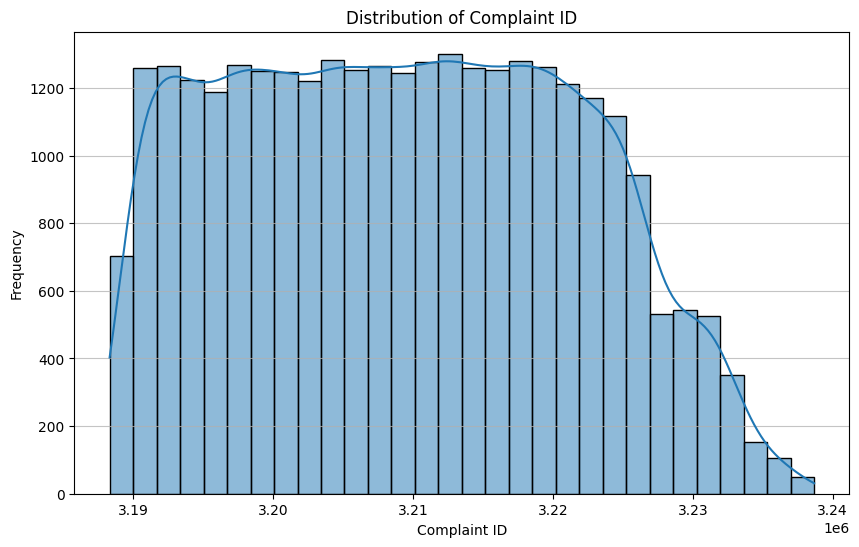


----------------------------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Plotting Histograms for Numerical Columns:\n")

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

if len(numerical_cols) == 0:
    print("No numerical columns found to plot histograms.")
else:
    for col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(axis='y', alpha=0.75)
        plt.show()
        print("\n" + "-" * 70 + "\n")

##Step 4: Bivariate and Multivariate Analysis

###Comparing two or more variables to find interactions.


--- Bivariate Analysis: Interactions between Variables ---

1. Product vs. Company response to consumer:

Company response to consumer                                                  Closed with explanation  Closed with monetary relief  Closed with non-monetary relief  In progress  Untimely response
Product                                                                                                                                                                                            
Checking or savings account                                                                      1359                          330                               73          451                  7
Credit card or prepaid card                                                                      1605                          375                              218          499                  3
Credit reporting, credit repair services, or other personal consumer reports                     7530         

<Figure size 1200x700 with 0 Axes>

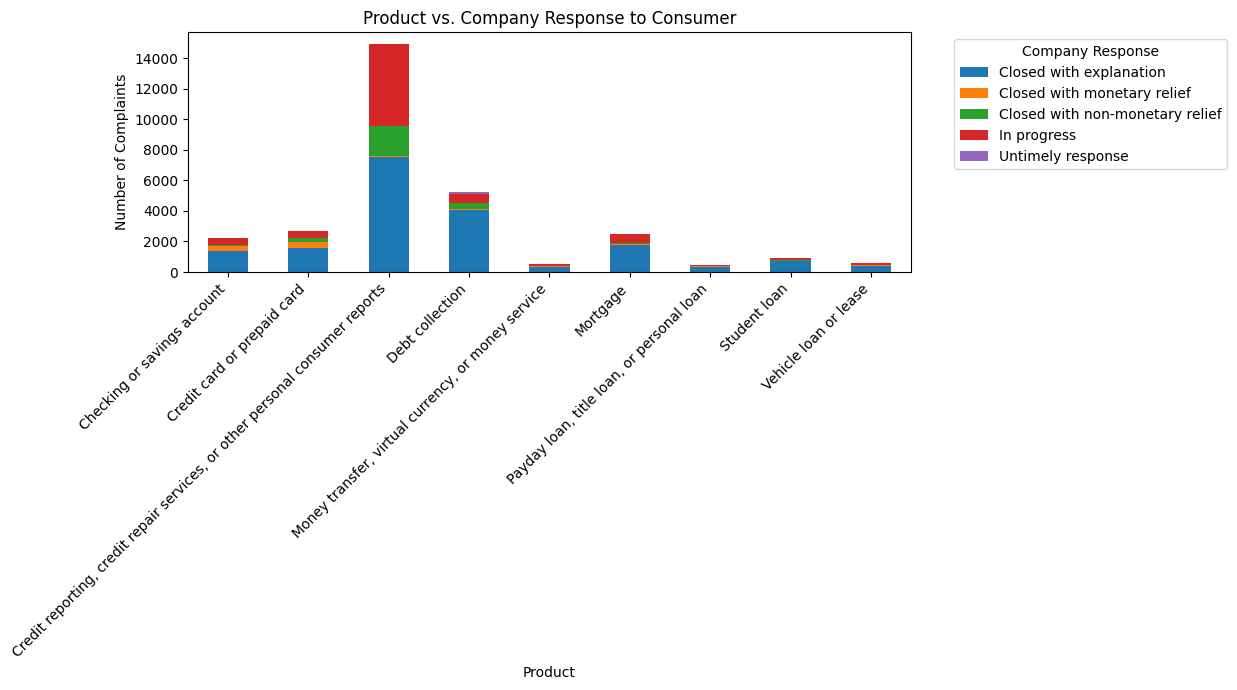


--------------------------------------------------------------------------------

2. Product vs. Timely response?:

Timely response?                                                               No    Yes
Product                                                                                 
Checking or savings account                                                    16   2204
Credit card or prepaid card                                                    17   2683
Credit reporting, credit repair services, or other personal consumer reports  107  14828
Debt collection                                                               165   5054
Money transfer, virtual currency, or money service                              7    506
Mortgage                                                                       11   2460
Payday loan, title loan, or personal loan                                      25    417
Student loan                                                                   23 

<Figure size 1200x700 with 0 Axes>

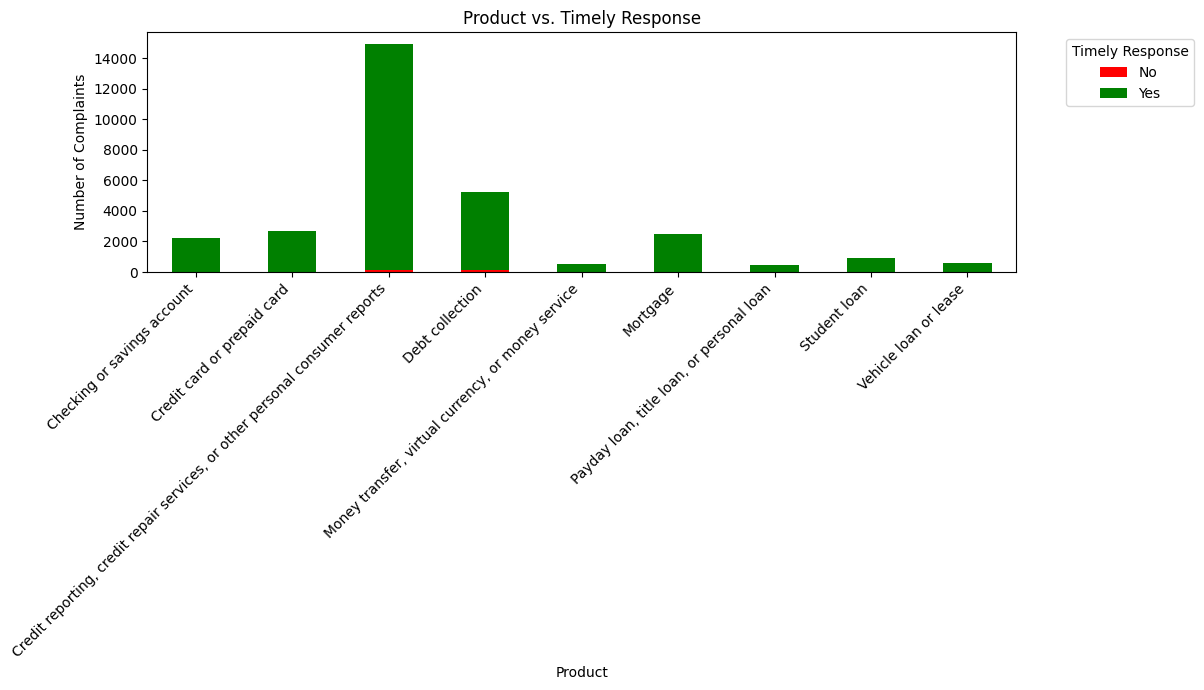


--------------------------------------------------------------------------------

3. Top 5 Issues for each Product (as an example):


Product: Checking or savings account
Issue
Managing an account                                             1463
Closing an account                                               248
Opening an account                                               202
Problem with a lender or other company charging your account     169
Problem caused by your funds being low                           121


/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')


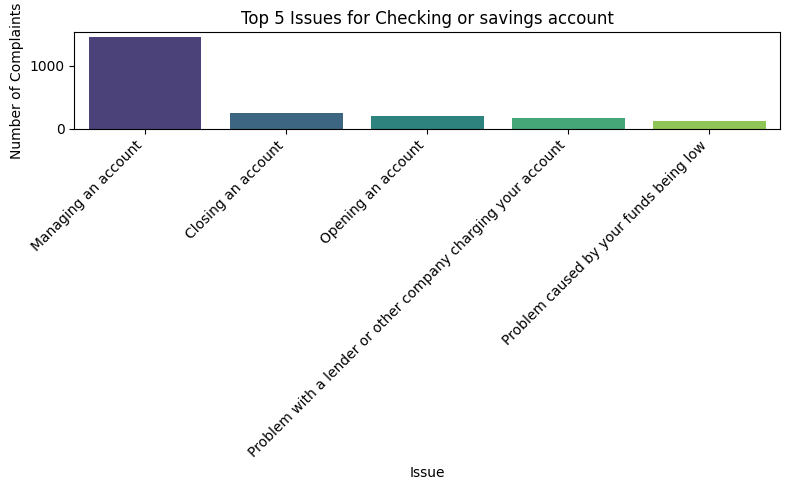


--------------------------------------------------------------------------------


Product: Debt collection
Issue
Attempts to collect debt not owed                      2578
Written notification about debt                        1010
Communication tactics                                   563
Took or threatened to take negative or legal action     498
False statements or representation                      427


/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')


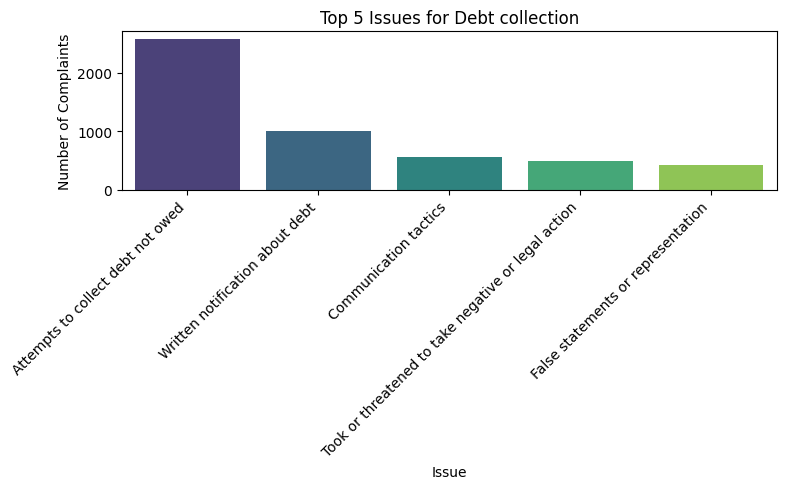


--------------------------------------------------------------------------------


Product: Credit reporting, credit repair services, or other personal consumer reports


/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')


Issue
Incorrect information on your report                                                9160
Problem with a credit reporting company's investigation into an existing problem    3533
Improper use of your report                                                         1305
Unable to get your credit report or credit score                                     395
Problem with fraud alerts or security freezes                                        306


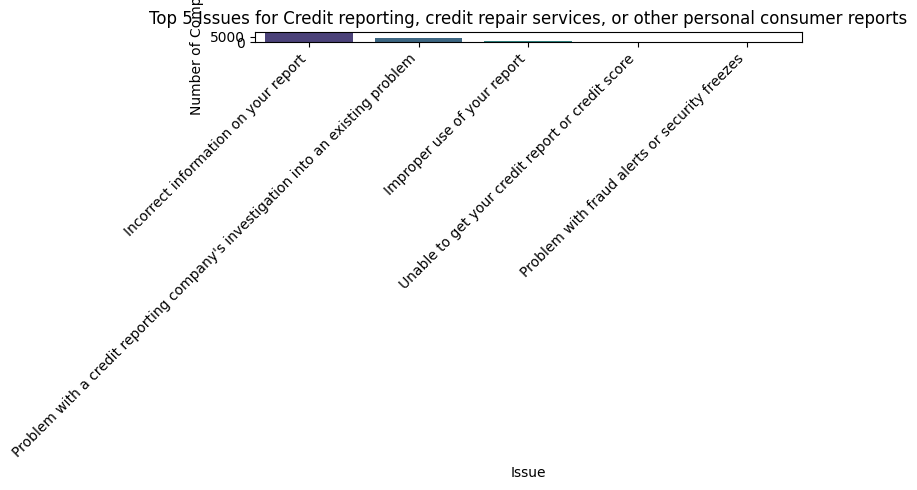


--------------------------------------------------------------------------------


Product: Mortgage
Issue
Trouble during payment process                                 1319
Struggling to pay mortgage                                      689
Applying for a mortgage or refinancing an existing mortgage     218
Closing on a mortgage                                           156
Incorrect information on your report                             48


/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')


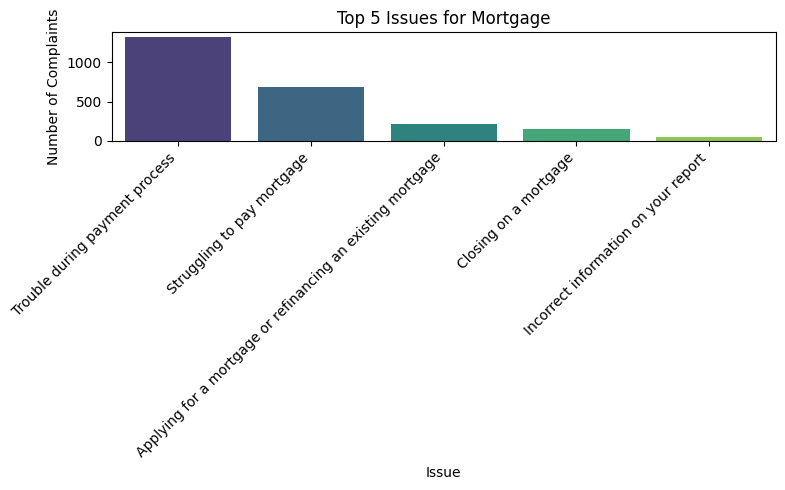

/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')



--------------------------------------------------------------------------------


Product: Student loan
Issue
Dealing with your lender or servicer                                                646
Struggling to repay your loan                                                       196
Incorrect information on your report                                                 36
Getting a loan                                                                       23
Problem with a credit reporting company's investigation into an existing problem     12


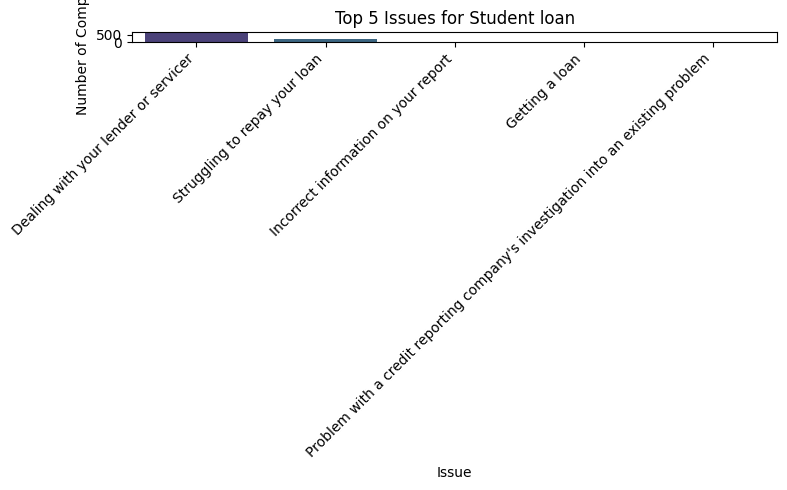

/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')



--------------------------------------------------------------------------------


Product: Vehicle loan or lease
Issue
Managing the loan or lease                  206
Problems at the end of the loan or lease    113
Struggling to pay your loan                  92
Getting a loan or lease                      78
Incorrect information on your report         52


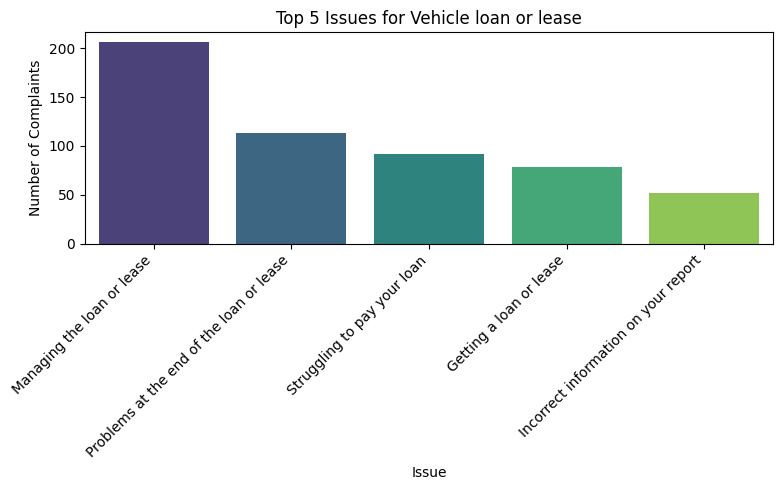


--------------------------------------------------------------------------------


Product: Credit card or prepaid card
Issue
Problem with a purchase shown on your statement    673
Other features, terms, or problems                 346
Fees or interest                                   308
Problem when making payments                       280
Getting a credit card                              273


/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')


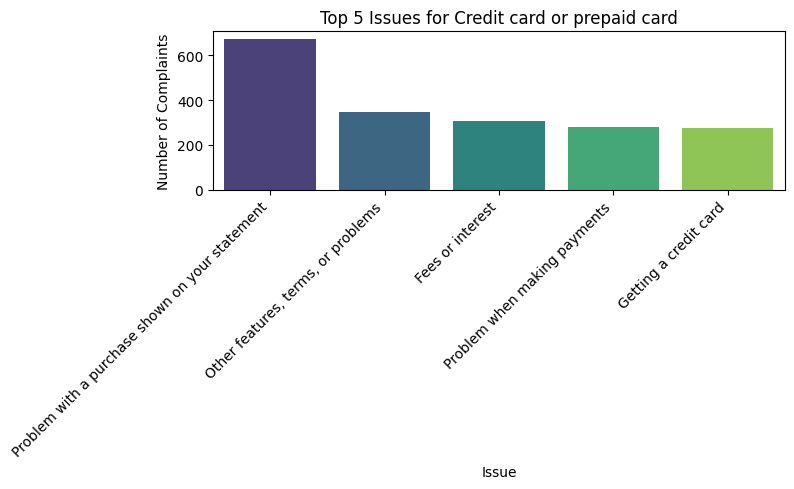


--------------------------------------------------------------------------------


Product: Payday loan, title loan, or personal loan
Issue
Charged fees or interest you didn't expect                100
Struggling to pay your loan                                84
Problem when making payments                               67
Problem with the payoff process at the end of the loan     41
Incorrect information on your report                       25


/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')


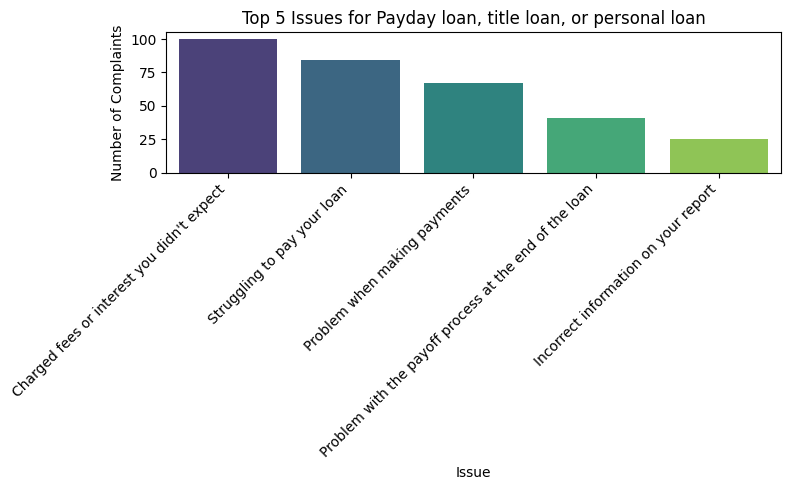

/tmp/ipykernel_1416/2932698663.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')



--------------------------------------------------------------------------------


Product: Money transfer, virtual currency, or money service
Issue
Fraud or scam                                               209
Other transaction problem                                   104
Money was not available when promised                        53
Unauthorized transactions or other transaction problem       38
Managing, opening, or closing your mobile wallet account     30


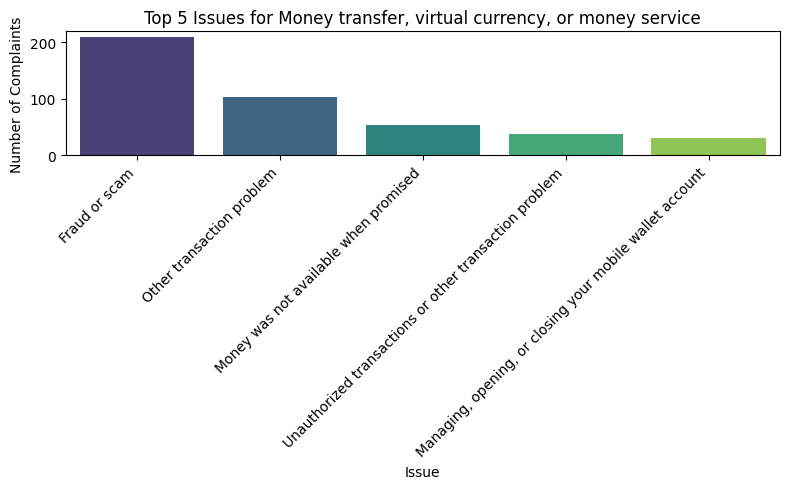


--------------------------------------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Bivariate Analysis: Interactions between Variables ---\n")

# Interaction 1: Product vs. Company response to consumer
print("1. Product vs. Company response to consumer:\n")
product_response_crosstab = pd.crosstab(df['Product'], df['Company response to consumer'])
print(product_response_crosstab.to_string())

plt.figure(figsize=(12, 7))
product_response_crosstab.plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title('Product vs. Company Response to Consumer')
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Company Response', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n" + "-" * 80 + "\n")

# Interaction 2: Product vs. Timely response?
print("2. Product vs. Timely response?:\n")
product_timely_crosstab = pd.crosstab(df['Product'], df['Timely response?'])
print(product_timely_crosstab.to_string())

plt.figure(figsize=(12, 7))
product_timely_crosstab.plot(kind='bar', stacked=True, figsize=(12, 7), color=['red', 'green'])
plt.title('Product vs. Timely Response')
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Timely Response', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print("\n" + "-" * 80 + "\n")

# Interaction 3: Top 5 Issues by Product (example for one product)
print("3. Top 5 Issues for each Product (as an example):\n")
for product in df['Product'].unique():
    print(f"\nProduct: {product}")
    top_issues = df[df['Product'] == product]['Issue'].value_counts().head(5)
    print(top_issues.to_string())
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_issues.index, y=top_issues.values, palette='viridis')
    plt.title(f'Top 5 Issues for {product}')
    plt.xlabel('Issue')
    plt.ylabel('Number of Complaints')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("\n" + "-" * 80 + "\n")

--- Continuing Bivariate Analysis: Top 5 Issues by Product ---


Product: Checking or savings account
Issue
Managing an account                                             1463
Closing an account                                               248
Opening an account                                               202
Problem with a lender or other company charging your account     169
Problem caused by your funds being low                           121


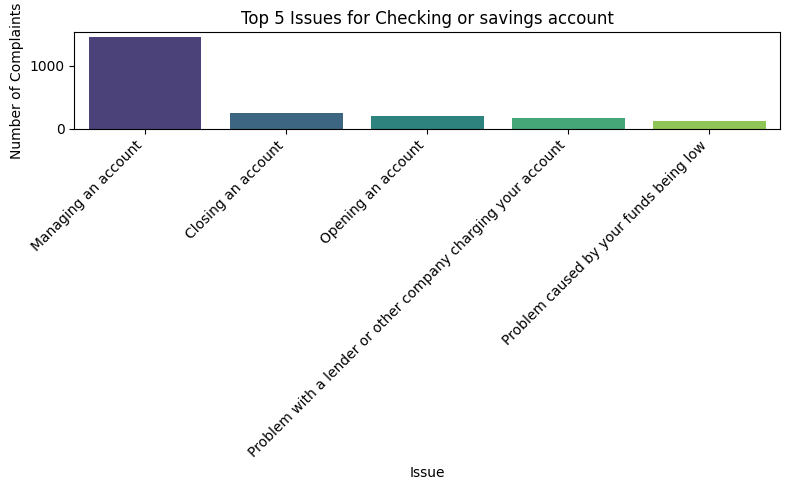


--------------------------------------------------------------------------------


Product: Debt collection
Issue
Attempts to collect debt not owed                      2578
Written notification about debt                        1010
Communication tactics                                   563
Took or threatened to take negative or legal action     498
False statements or representation                      427


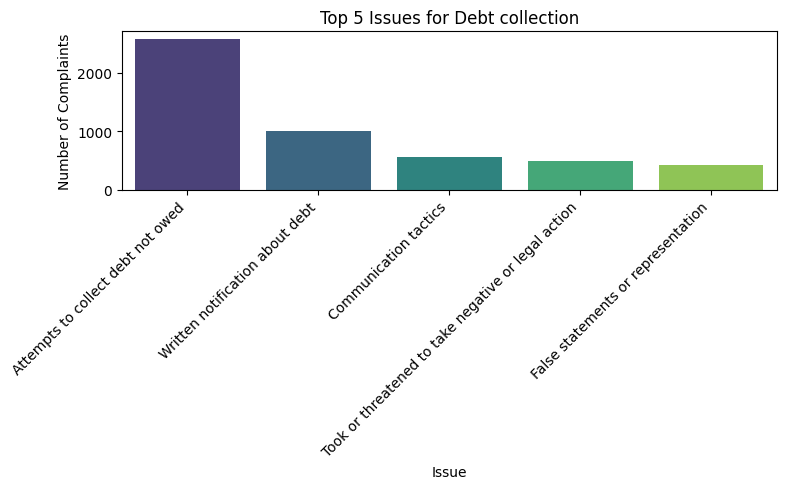


--------------------------------------------------------------------------------


Product: Credit reporting, credit repair services, or other personal consumer reports
Issue
Incorrect information on your report                                                9160
Problem with a credit reporting company's investigation into an existing problem    3533
Improper use of your report                                                         1305
Unable to get your credit report or credit score                                     395
Problem with fraud alerts or security freezes                                        306


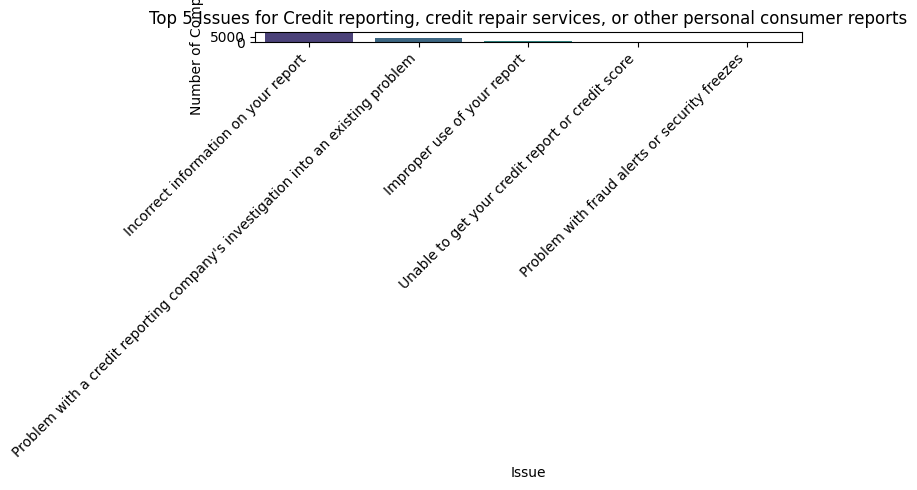


--------------------------------------------------------------------------------


Product: Mortgage
Issue
Trouble during payment process                                 1319
Struggling to pay mortgage                                      689
Applying for a mortgage or refinancing an existing mortgage     218
Closing on a mortgage                                           156
Incorrect information on your report                             48


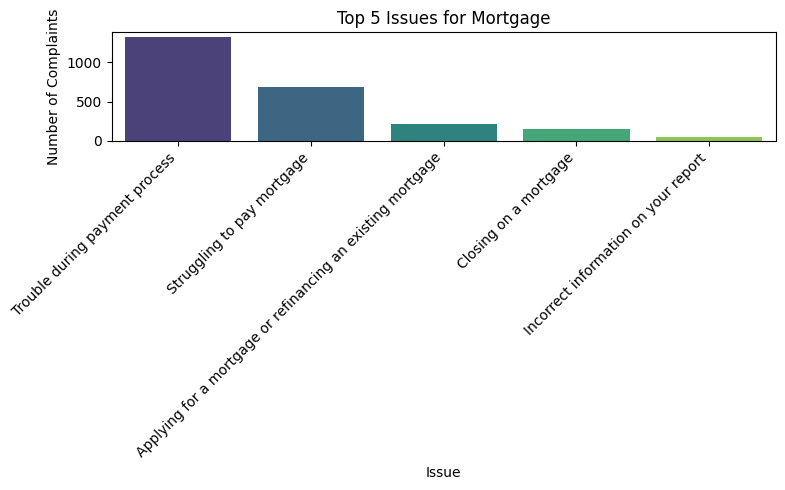


--------------------------------------------------------------------------------


Product: Student loan
Issue
Dealing with your lender or servicer                                                646
Struggling to repay your loan                                                       196
Incorrect information on your report                                                 36
Getting a loan                                                                       23
Problem with a credit reporting company's investigation into an existing problem     12


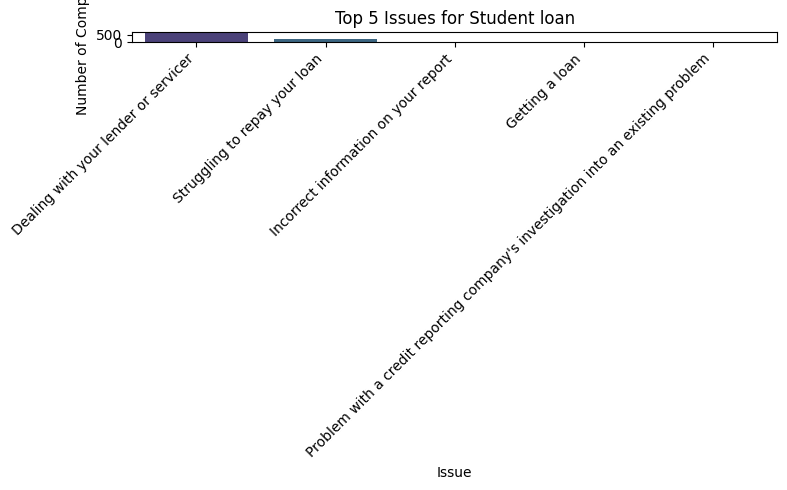


--------------------------------------------------------------------------------


Product: Vehicle loan or lease
Issue
Managing the loan or lease                  206
Problems at the end of the loan or lease    113
Struggling to pay your loan                  92
Getting a loan or lease                      78
Incorrect information on your report         52


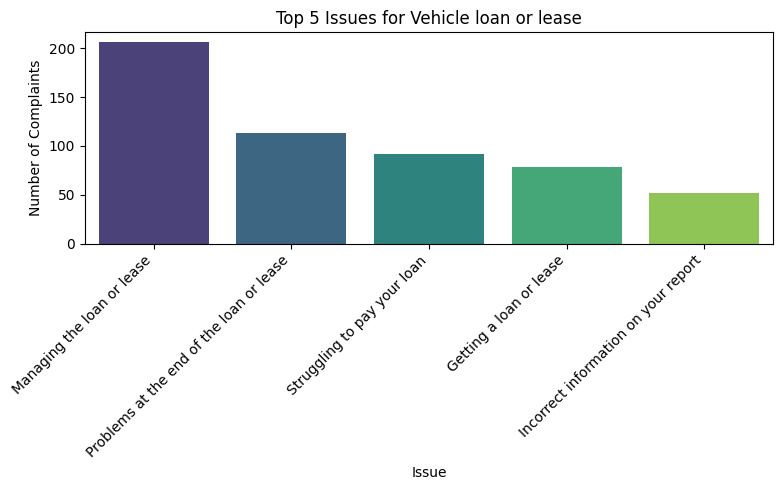


--------------------------------------------------------------------------------


Product: Credit card or prepaid card
Issue
Problem with a purchase shown on your statement    673
Other features, terms, or problems                 346
Fees or interest                                   308
Problem when making payments                       280
Getting a credit card                              273


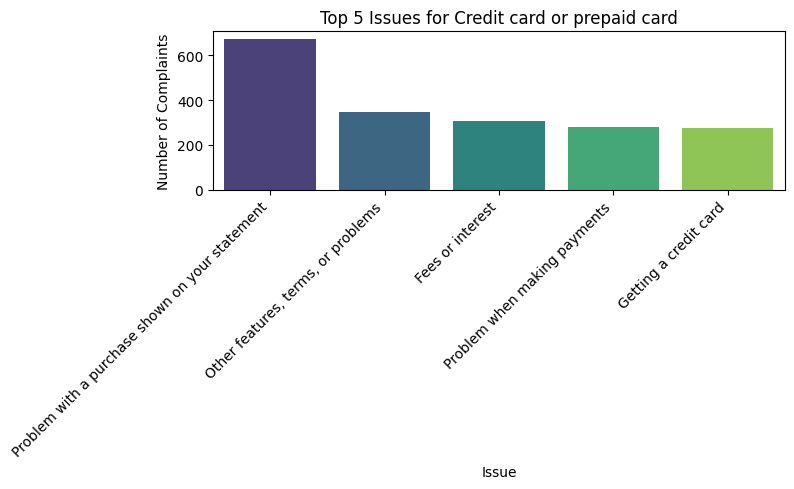


--------------------------------------------------------------------------------


Product: Payday loan, title loan, or personal loan
Issue
Charged fees or interest you didn't expect                100
Struggling to pay your loan                                84
Problem when making payments                               67
Problem with the payoff process at the end of the loan     41
Incorrect information on your report                       25


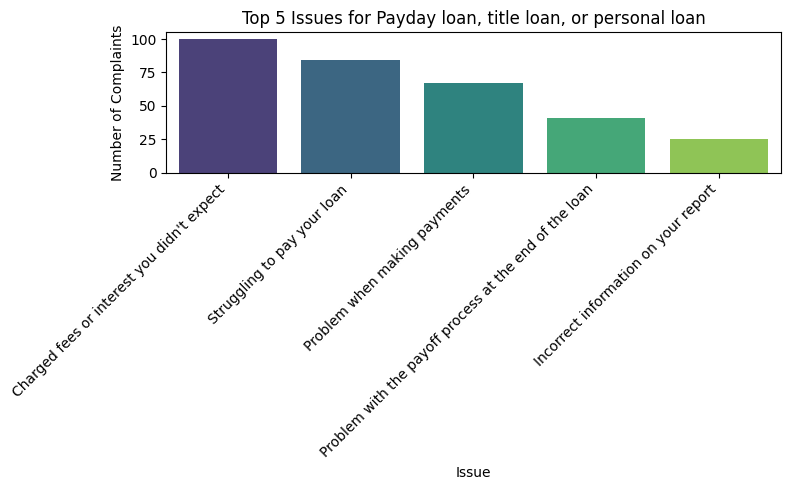


--------------------------------------------------------------------------------


Product: Money transfer, virtual currency, or money service
Issue
Fraud or scam                                               209
Other transaction problem                                   104
Money was not available when promised                        53
Unauthorized transactions or other transaction problem       38
Managing, opening, or closing your mobile wallet account     30


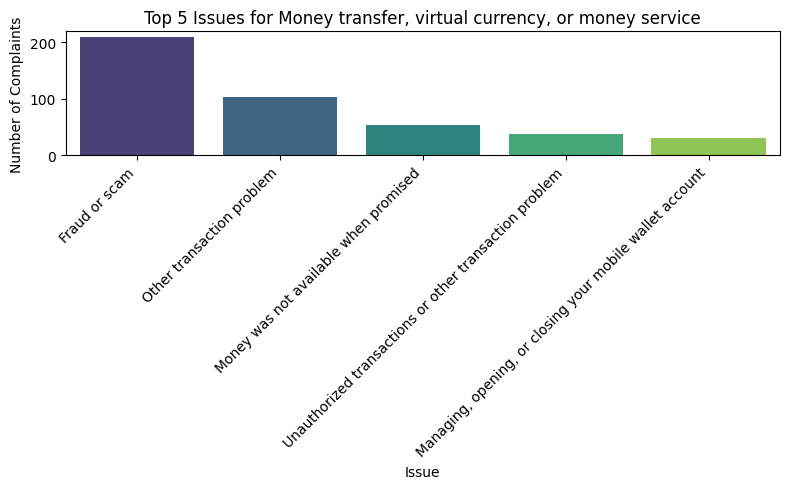


--------------------------------------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Continuing Bivariate Analysis: Top 5 Issues by Product ---\n")

# Interaction 3: Top 5 Issues by Product
for product in df['Product'].unique():
    print(f"\nProduct: {product}")
    top_issues = df[df['Product'] == product]['Issue'].value_counts().head(5)
    print(top_issues.to_string())
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_issues.index, y=top_issues.values, hue=top_issues.index, palette='viridis', legend=False)
    plt.title(f'Top 5 Issues for {product}')
    plt.xlabel('Issue')
    plt.ylabel('Number of Complaints')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("\n" + "-" * 80 + "\n")

###Using scatter plots for numeric variables.

--- Visualizing 'Complaint ID' against Categorical Variable ('Product') ---



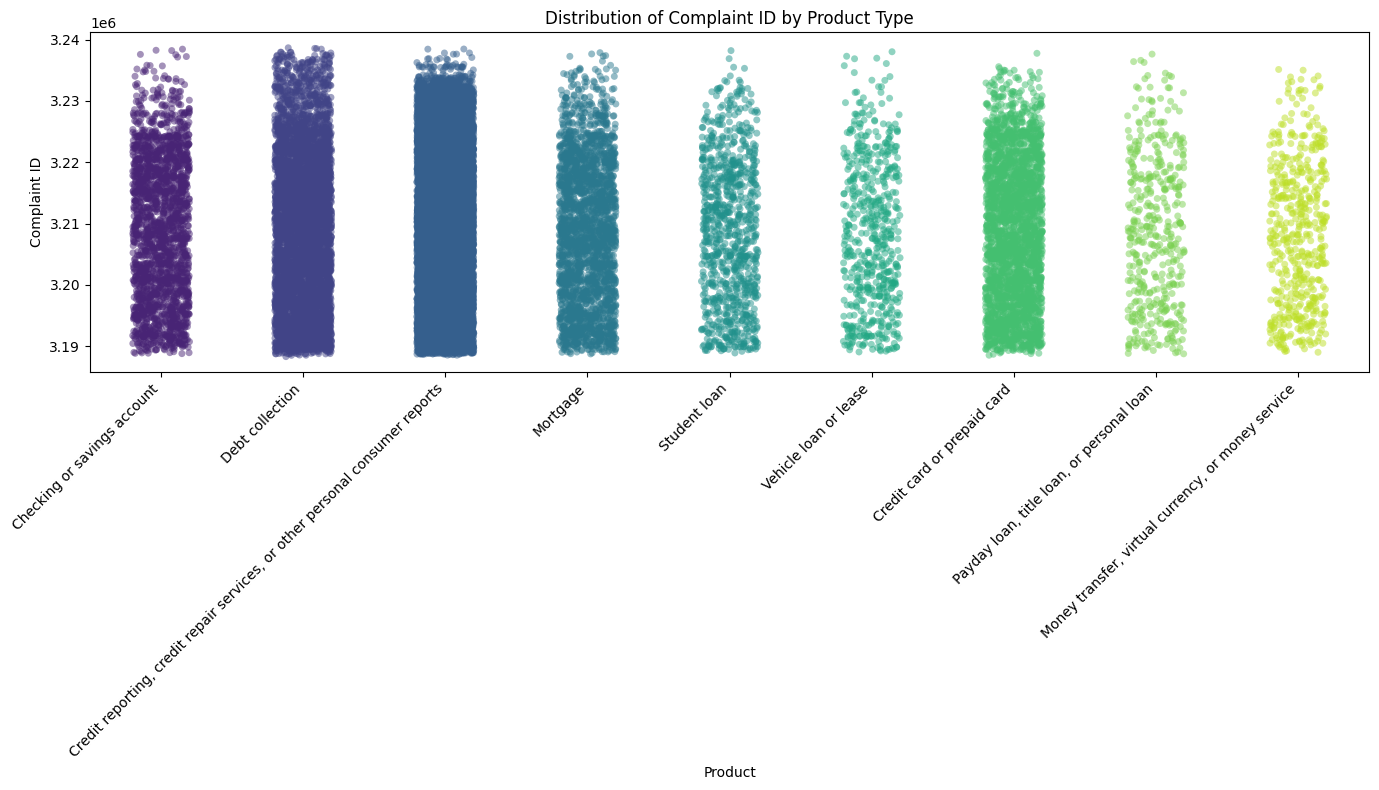


--- Analysis Complete ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualizing 'Complaint ID' against Categorical Variable ('Product') ---\n")

# Using a stripplot to visualize the distribution of Complaint ID across Product categories
# This provides a 'scatter-like' view for one numeric and one categorical variable.
plt.figure(figsize=(14, 8))
sns.stripplot(x='Product', y='Complaint ID', data=df, jitter=0.2, alpha=0.5, hue='Product', palette='viridis', legend=False)
plt.title('Distribution of Complaint ID by Product Type')
plt.xlabel('Product')
plt.ylabel('Complaint ID')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Analysis Complete ---")

###Generating correlation matrices and heatmaps to check linear relationships

In [ ]:
print("--- Generating Correlation Matrix and Heatmap ---")

# Re-identifying numerical columns to be safe
numerical_cols_for_corr = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if len(numerical_cols_for_corr) < 2:
    print(f"\nCannot generate a correlation matrix or heatmap. The dataset contains only {len(numerical_cols_for_corr)} numerical variable(s).")
    print(f"Numerical variables found: {numerical_cols_for_corr}")
    print("At least two numerical variables are required to compute linear correlations.")
else:
    # Select only numerical columns for correlation calculation
    df_numerical = df[numerical_cols_for_corr]

    # Calculate the correlation matrix
    correlation_matrix = df_numerical.corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix.to_string())

    # Generate a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Variables')
    plt.show()

print("\n--- Correlation Analysis Complete ---")

--- Generating Correlation Matrix and Heatmap ---

Cannot generate a correlation matrix or heatmap. The dataset contains only 1 numerical variable(s).
Numerical variables found: ['Complaint ID']
At least two numerical variables are required to compute linear correlations.

--- Correlation Analysis Complete ---


##Step 5: Outliers and Feature Engineering

###Detecting Outliers

--- Detecting Outliers in Numerical Columns ---

Analyzing outliers for column: 'Complaint ID'
  Q1 (25th percentile): 3199177.75
  Q3 (75th percentile): 3219153.25
  IQR: 19975.5
  Lower Bound for Outliers: 3169214.5
  Upper Bound for Outliers: 3249116.5
  Number of outliers detected: 0
  No outliers detected based on the IQR method.


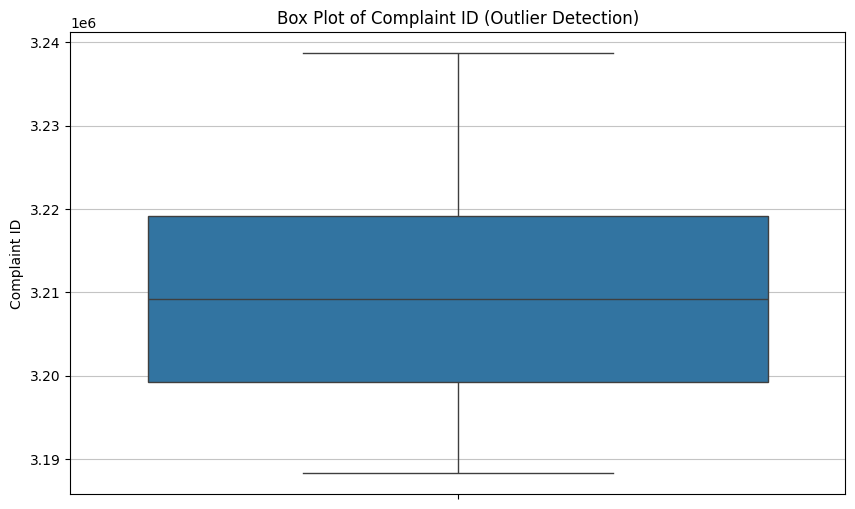


----------------------------------------------------------------------

--- Outlier Detection Complete ---


In [ ]:
print("--- Detecting Outliers in Numerical Columns ---")

import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if not numerical_cols:
    print("No numerical columns found for outlier detection.")
else:
    for col in numerical_cols:
        print(f"\nAnalyzing outliers for column: '{col}'")

        # Calculate IQR for outlier detection
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        print(f"  Q1 (25th percentile): {Q1}")
        print(f"  Q3 (75th percentile): {Q3}")
        print(f"  IQR: {IQR}")
        print(f"  Lower Bound for Outliers: {lower_bound}")
        print(f"  Upper Bound for Outliers: {upper_bound}")
        print(f"  Number of outliers detected: {len(outliers)}")

        if not outliers.empty:
            print("  Sample of Outlier Values (first 5):\n")
            print(outliers[col].head().to_string())
        else:
            print("  No outliers detected based on the IQR method.")

        # Visualize outliers using a box plot
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col} (Outlier Detection)')
        plt.ylabel(col)
        plt.grid(axis='y', alpha=0.75)
        plt.show()
        print("\n" + "-" * 70 + "\n")

print("--- Outlier Detection Complete ---")

###Removing or transforming outliers if they skew analysis.

In [ ]:
print("--- Handling Outliers/Infrequent Categories ---")

# 1. Handling numerical column outliers
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if numerical_cols:
    print(f"\nNo outliers were detected in numerical column(s) {numerical_cols} using the IQR method. No action needed.")
else:
    print("\nNo numerical columns found to check for outliers.")

# 2. Handling infrequent categories in categorical columns
# Define a threshold for 'rare' categories (e.g., less than 1% of total observations)
threshold_percentage = 0.01 # 1%

categorical_cols_to_process = [
    'Sub-product',
    'Sub-issue',
    'Company public response',
    'State',
    'Tags'
] # Select columns likely to have many rare categories

print(f"\nGrouping categories less than {threshold_percentage * 100}% into 'Other' for selected categorical columns:")

for col in categorical_cols_to_process:
    if col in df.columns and df[col].dtype == 'object':
        total_count = len(df)
        value_counts = df[col].value_counts()

        # Identify rare categories
        rare_categories = value_counts[value_counts / total_count < threshold_percentage].index

        if not rare_categories.empty:
            print(f"\n--- Column: '{col}' ---")
            print(f"  Original unique values: {df[col].nunique()}")
            print(f"  Number of rare categories (below {threshold_percentage*100}%): {len(rare_categories)}")

            # Replace rare categories with 'Other_{col_name}'
            df[col] = df[col].replace(rare_categories, f'Other_{col}')

            print(f"  New unique values after grouping: {df[col].nunique()}")
            print("  Top 10 value counts after grouping:")
            print(df[col].value_counts().head(10).to_string())
        else:
            print(f"\nColumn: '{col}' has no categories below the {threshold_percentage*100}% threshold. No grouping performed.")
    elif col not in df.columns:
        print(f"\nColumn '{col}' not found in DataFrame. Skipping.")
    else:
        print(f"\nColumn '{col}' is not of object type. Skipping for infrequent category grouping.")

print("\n--- Outlier/Infrequent Category Handling Complete ---")

--- Handling Outliers/Infrequent Categories ---

No outliers were detected in numerical column(s) ['Complaint ID'] using the IQR method. No action needed.

Grouping categories less than 1.0% into 'Other' for selected categorical columns:

--- Column: 'Sub-product' ---
  Original unique values: 46
  Number of rare categories (below 1.0%): 33
  New unique values after grouping: 14
  Top 10 value counts after grouping:
Sub-product
Credit reporting                              14670
Other_Sub-product                              3234
General-purpose credit card or charge card     2066
Checking account                               1677
Conventional home mortgage                     1516
Other debt                                     1395
Credit card debt                               1192
I do not know                                  1104
Medical debt                                    920
Federal student loan servicing                  627

--- Column: 'Sub-issue' ---
  Original unique v

###Spotting extreme values using Z-scores or Interquartile Range (IQR).

In [ ]:
print("--- Spotting Extreme Values (Z-scores) ---")

# Re-identifying numerical columns to ensure we work with the latest DataFrame state
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

if not numerical_cols:
    print("No numerical columns found to spot extreme values using Z-scores.")
else:
    for col in numerical_cols:
        print(f"\nAnalyzing extreme values for column: '{col}' using Z-score")

        # Calculate Z-scores
        mean = df[col].mean()
        std_dev = df[col].std()

        if std_dev == 0:
            print(f"  Standard deviation for '{col}' is zero. Cannot calculate Z-scores.")
            continue

        df['z_score_' + col] = (df[col] - mean) / std_dev

        # Define a Z-score threshold for extreme values (commonly 2, 2.5, or 3 standard deviations)
        z_score_threshold = 3

        # Identify extreme values based on Z-score
        extreme_values_zscore = df[ (df['z_score_' + col].abs() > z_score_threshold) ]

        print(f"  Mean of '{col}': {mean:.2f}")
        print(f"  Standard Deviation of '{col}': {std_dev:.2f}")
        print(f"  Number of extreme values detected (Z-score > {z_score_threshold} or < -{z_score_threshold}): {len(extreme_values_zscore)}")

        if not extreme_values_zscore.empty:
            print("  Sample of Extreme Values (first 5, with original value and z-score):\n")
            print(extreme_values_zscore[[col, 'z_score_' + col]].head().to_string())
        else:
            print("  No extreme values detected based on the Z-score method (threshold: +/-3).")

        # Drop the temporary z_score column if not needed for further analysis
        df = df.drop(columns=['z_score_' + col])

print("\n--- Extreme Value Spotting Complete ---")

--- Spotting Extreme Values (Z-scores) ---

Analyzing extreme values for column: 'Complaint ID' using Z-score
  Mean of 'Complaint ID': 3209420.72
  Standard Deviation of 'Complaint ID': 12028.17
  Number of extreme values detected (Z-score > 3 or < -3): 0
  No extreme values detected based on the Z-score method (threshold: +/-3).

--- Extreme Value Spotting Complete ---


###Creating new variables or scale data to prepare for modeling.

In [ ]:
print("--- Feature Engineering: Creating New Variables from Dates ---")

# 1. Convert date columns to datetime objects
df['Date received'] = pd.to_datetime(df['Date received'])
df['Date sent to company'] = pd.to_datetime(df['Date sent to company'])
print("Converted 'Date received' and 'Date sent to company' to datetime objects.")

# 2. Create new time-based features from 'Date received'
df['Complaint_Received_Year'] = df['Date received'].dt.year
df['Complaint_Received_Month'] = df['Date received'].dt.month
df['Complaint_Received_Day'] = df['Date received'].dt.day
df['Complaint_Received_DayOfWeek'] = df['Date received'].dt.dayofweek # Monday=0, Sunday=6
print("Extracted year, month, day, and day of week from 'Date received'.")

# 3. Create new time-based features from 'Date sent to company'
df['Complaint_Sent_Year'] = df['Date sent to company'].dt.year
df['Complaint_Sent_Month'] = df['Date sent to company'].dt.month
df['Complaint_Sent_Day'] = df['Date sent to company'].dt.day
df['Complaint_Sent_DayOfWeek'] = df['Date sent to company'].dt.dayofweek
print("Extracted year, month, day, and day of week from 'Date sent to company'.")

# 4. Calculate 'Complaint duration' (time from receipt to sending to company)
df['Complaint_Duration_Days'] = (df['Date sent to company'] - df['Date received']).dt.days
print("Calculated 'Complaint_Duration_Days'.")

# Display the first few rows with new features and their info to verify
print("\nDataFrame head with new date features (first 5 rows):")
print(df[['Date received', 'Date sent to company', 'Complaint_Received_Year', 'Complaint_Duration_Days']].head().to_string())

print("\nNew numerical features created. These can now be considered for scaling or further analysis.")
print("--- Feature Engineering Complete ---")

print("\n--- Scaling Numerical Features ---")
from sklearn.preprocessing import StandardScaler

# Identify all numerical columns (including 'Complaint ID' and newly created date features)
numerical_features_to_scale = [
    'Complaint ID',
    'Complaint_Received_Year',
    'Complaint_Received_Month',
    'Complaint_Received_Day',
    'Complaint_Received_DayOfWeek',
    'Complaint_Sent_Year',
    'Complaint_Sent_Month',
    'Complaint_Sent_Day',
    'Complaint_Sent_DayOfWeek',
    'Complaint_Duration_Days'
]

# Filter to only include columns actually present in the DataFrame
numerical_features_to_scale = [col for col in numerical_features_to_scale if col in df.columns]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical features
df[numerical_features_to_scale] = scaler.fit_transform(df[numerical_features_to_scale])

print(f"Scaled the following numerical features using StandardScaler: {numerical_features_to_scale}")

print("\nDataFrame head with scaled numerical features (first 5 rows):")
print(df[numerical_features_to_scale].head().to_string())

print("--- Scaling Complete ---")

print("\n--- Encoding Categorical Features ---")

# Drop original date columns as we have extracted features from them
df = df.drop(columns=['Date received', 'Date sent to company'])
print("Dropped original 'Date received' and 'Date sent to company' columns.")

# Identify categorical columns for one-hot encoding (excluding numerical and now-dropped date columns)
categorical_features_to_encode = df.select_dtypes(include='object').columns.tolist()

if not categorical_features_to_encode:
    print("No object-type columns found for encoding.")
else:
    print(f"Applying One-Hot Encoding to the following categorical features: {categorical_features_to_encode}")
    df = pd.get_dummies(df, columns=categorical_features_to_encode, drop_first=True)
    print("One-Hot Encoding complete.")
    print(f"New DataFrame shape: {df.shape}")
    print("\nDataFrame head with encoded features (first 5 rows):")
    print(df.head().to_string())

print("--- Encoding Complete ---")

--- Feature Engineering: Creating New Variables from Dates ---
Converted 'Date received' and 'Date sent to company' to datetime objects.
Extracted year, month, day, and day of week from 'Date received'.
Extracted year, month, day, and day of week from 'Date sent to company'.
Calculated 'Complaint_Duration_Days'.

DataFrame head with new date features (first 5 rows):
  Date received Date sent to company  Complaint_Received_Year  Complaint_Duration_Days
0    2019-05-10           2019-05-10                     2019                        0
1    2019-05-10           2019-05-10                     2019                        0
2    2019-05-10           2019-05-10                     2019                        0
3    2019-05-10           2019-05-10                     2019                        0
4    2019-05-10           2019-05-10                     2019                        0

New numerical features created. These can now be considered for scaling or further analysis.
--- Feature Eng

##Step 6: Exporting the cleaned dataset to the local system

###Downloading Directly to Local Computer (CSV Format)

In [ ]:
# Save DataFrame to a local CSV file in Colab
cleaned_file_path = '/content/cleaned_consumer_complaints.csv'
df.to_csv(cleaned_file_path, index=False)

# Trigger automatic browser download
from google.colab import files
files.download(cleaned_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Editing table and downloading it to use in BigQuery

In [ ]:
# Rename specific columns that contain special characters or spaces
df = df.rename(
    columns={
        'Consumer consent provided?': 'Consumer_consent_provided',
        'Date received': 'Date_received',
        'Sub-product': 'Sub_product',
        'Sub-issue': 'Sub_issue',
        'Consumer complaint narrative': 'Consumer_complaint_narrative',
        'Company public response': 'Company_public_response',
        'ZIP code': 'ZIP_code',
        'Date sent to company': 'Date_sent_to_company',
        'Company response to consumer': 'Company_response_to_consumer',
        'Timely response?': 'Timely_response',
        'Consumer disputed?': 'Consumer_disputed',
        'Complaint ID': 'Complaint_ID',
    }
)

# Export the newly renamed columns to a fresh CSV file for your upload
cleaned_file_path = '/content/fixed_consumer_complaints.csv'
df.to_csv(cleaned_file_path, index=False)
print('Columns renamed successfully! Ready for upload.')

Columns renamed successfully! Ready for upload.


###Exporting and downloading the dataset in CSV format with the newly renamed columns

In [ ]:
# 1. Save the file inside Colab
export_path = '/content/cleaned_consumer_complaints_new.csv'
df.to_csv(export_path, index=False)

# 2. Trigger the download to your system
from google.colab import files
files.download(export_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>